# 02 — Fairness & Explainability (Responsible AI)

Notebook trình bày phần Responsible AI. **Không chứa logic riêng** — mọi hàm nằm trong `src/credit_risk/responsible_ai/`
(`fairness.py`, `explainability.py`, `privacy.py`, `analysis.py`). Nguồn số liệu chính thức là
`make responsible-ai` → `reports/fairness_report.{json,md}`, `reports/explainability_report.{json,md}`,
`reports/figures/rai_*.png`; notebook tính lại một phần trực tiếp và **kiểm tra khớp** với report.

Nội dung:
1. Dữ liệu đánh giá và thành phần nhóm nhạy cảm
2. Fairness audit (Fairlearn): DPD, EOD, approval rate, TPR/FPR theo `SEX`, nhóm tuổi, `EDUCATION`, `MARRIAGE`
3. Mitigation: reweighing, unawareness, ThresholdOptimizer — trade-off fairness ↔ ROC-AUC ↔ expected loss
4. SHAP global + local, LIME cho cùng chủ thẻ, độ đồng thuận SHAP↔LIME
5. Giải thích phía serving (`/api/v1/explain`)
6. Privacy: redaction log, pseudonymization, generalization

Chạy lại: `make notebook-rai` (sau `make train` và `make responsible-ai`).

In [1]:
import json
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from IPython.display import Image, Markdown, display

from credit_risk.config.settings import load_settings
from credit_risk.data.schema import ALL_FEATURES, TARGET_COLUMN
from credit_risk.responsible_ai import explainability as xai
from credit_risk.responsible_ai import fairness
from credit_risk.responsible_ai.analysis import (
    load_champion,
    load_evaluation_data,
    load_rai_config,
    load_training_split,
    select_profiles,
)

# credit_risk plotting modules select the headless Agg backend on import; restore inline rendering.
%matplotlib inline
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.float_format", "{:.4f}".format)

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
settings = load_settings(project_root=ROOT)
cfg = load_rai_config(ROOT / "configs" / "responsible_ai.yaml")
REPORTS = ROOT / "reports"
fairness_report = json.loads((REPORTS / "fairness_report.json").read_text(encoding="utf-8"))
explain_report = json.loads((REPORTS / "explainability_report.json").read_text(encoding="utf-8"))

champion = load_champion(settings)
evaluation = load_evaluation_data(settings)
x_train, y_train = load_training_split(settings)
serving = settings.serving
print(f"Champion: {champion.candidate} {champion.params} | version {champion.version} | threshold {champion.threshold}")
print(f"Evaluation rows: {len(evaluation):,} | training rows: {len(x_train):,}")

/Users/thaycacac/Documents/mse/ky4/DDM501/ddm501/final-project/DDM501_Group5/FinalProject/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Champion: logistic_regression {'C': 0.008433492996539142} | version 1 | threshold 0.5
Evaluation rows: 10,000 | training rows: 12,000


## 1. Dữ liệu đánh giá

Model chỉ được train trên chủ thẻ **≥ 30 tuổi** (`train_baseline`). Để audit công bằng, dùng 10,000 chủ thẻ
**chưa từng train**: `stream_normal` (≥ 30 tuổi) + `stream_drifted` ghép nhãn trễ `ground_truth_feedback` (< 30 tuổi).

In [2]:
features, target = evaluation[ALL_FEATURES], evaluation[TARGET_COLUMN]
sensitive = fairness.sensitive_frame(features)
composition = (
    pd.concat([sensitive, target], axis=1)
    .melt(id_vars=TARGET_COLUMN, var_name="attribute", value_name="group")
    .groupby(["attribute", "group"])[TARGET_COLUMN]
    .agg(n="size", default_rate="mean")
)
composition["share"] = composition["n"] / len(evaluation)
composition

n  default_rate  share
attribute group                                     
EDUCATION graduate_school  3504        0.2306 0.3504
          high_school      1598        0.2616 0.1598
          others            162        0.2654 0.0162
          university       4736        0.2458 0.4736
MARRIAGE  married          4595        0.2468 0.4595
          others            137        0.2774 0.0137
          single           5268        0.2394 0.5268
SEX       female           6107        0.2338 0.6107
          male             3893        0.2582 0.3893
age_group 30-39            3263        0.2479 0.3263
          40-49            1310        0.2038 0.1310
          50+               427        0.1569 0.0427
          <30              5000        0.2580 0.5000

## 2. Fairness audit

- **DPD** (demographic parity difference) và **EOD** (equalized odds difference) tính bằng Fairlearn trên quyết định
  nhị phân tại threshold của champion.
- **Approval rate / disparate impact ratio** tính theo policy serving 3 mức (APPROVE khi P(default) < 0.30),
  so với four-fifths rule (0.8).

In [3]:
probabilities = np.asarray(champion.model.predict_proba(features))[:, 1]
audit = fairness.audit_fairness(
    target,
    probabilities,
    sensitive,
    attributes=cfg.attributes,
    threshold=champion.threshold,
    review_threshold=serving.review_threshold,
    decline_threshold=serving.decline_threshold,
    cost_fn=settings.training.cost_false_negative,
    cost_fp=settings.training.cost_false_positive,
    tolerances=cfg.thresholds,
)
summary = pd.DataFrame({attribute: result["summary"] for attribute, result in audit.items()}).T
summary["status"] = [audit[attribute]["status"] for attribute in summary.index]
summary

,demographic_parity_difference,demographic_parity_ratio,equalized_odds_difference,tpr_difference,fpr_difference,approval_rate_difference,disparate_impact_ratio,roc_auc_difference,status
SEX,0.0916,0.7688,0.0973,0.0379,0.0973,0.0697,0.7094,0.0194,WARN
age_group,0.1871,0.5126,0.1614,0.1087,0.1614,0.2442,0.4076,0.0111,WARN
EDUCATION,0.1147,0.7196,0.1052,0.0963,0.1052,0.1088,0.5879,0.0592,WARN
MARRIAGE,0.0357,0.9041,0.1159,0.1159,0.0202,0.0154,0.9320,0.0436,WARN


In [4]:
# Reproducibility: the live audit must match the committed report.
for attribute, result in audit.items():
    committed = fairness_report["audit"][attribute]["summary"]
    for metric, value in result["summary"].items():
        assert abs(value - committed[metric]) < 1e-5, (attribute, metric, value, committed[metric])
print("Live audit matches reports/fairness_report.json")

Live audit matches reports/fairness_report.json


,count,base_rate,selection_rate,approve_rate,review_rate,decline_rate,tpr,fpr,fnr,roc_auc,expected_loss
group,,,,,,,,,,,
<30,5000,0.2580,0.3838,0.1680,0.5814,0.2506,0.6481,0.2919,0.3519,0.7487,1.1246
30-39,3263,0.2479,0.3298,0.2136,0.5654,0.2210,0.6180,0.2347,0.3820,0.7476,1.1235
40-49,1310,0.2038,0.2481,0.3153,0.5145,0.1702,0.5393,0.1735,0.4607,0.7533,1.0771
50+,427,0.1569,0.1967,0.4122,0.4496,0.1382,0.5522,0.1306,0.4478,0.7422,0.8126


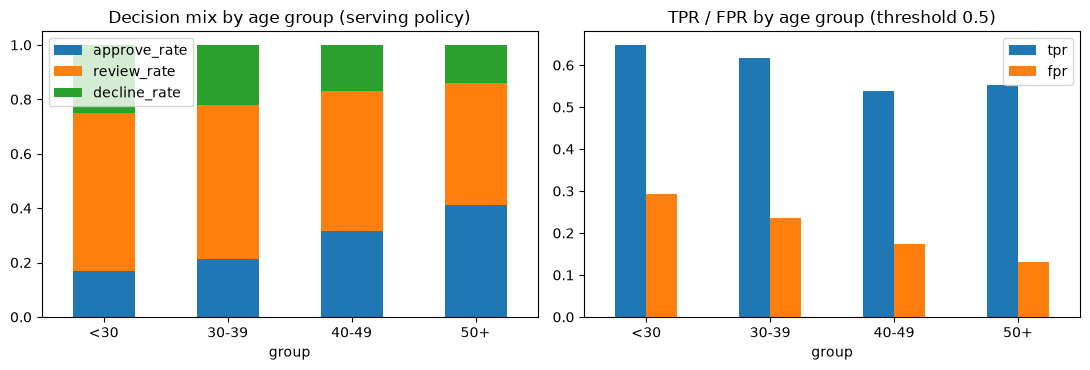

In [5]:
age_groups = pd.DataFrame(audit["age_group"]["groups"]).set_index("group")
display(age_groups)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
age_groups[["approve_rate", "review_rate", "decline_rate"]].plot.bar(stacked=True, ax=axes[0], rot=0)
axes[0].set_title("Decision mix by age group (serving policy)")
age_groups[["tpr", "fpr"]].plot.bar(ax=axes[1], rot=0)
axes[1].set_title("TPR / FPR by age group (threshold 0.5)")
plt.tight_layout()
plt.show()

**Nhận xét.** Nhóm `<30` — nhóm model chưa từng thấy khi train — có approval rate thấp nhất và FPR cao nhất: nhiều người
trẻ *không vỡ nợ* vẫn bị dự đoán vỡ nợ. Default rate thực tế chỉ chênh vài điểm phần trăm so với `30-39`, nên phần lớn
chênh lệch approval không được giải thích bởi rủi ro thực. Chi tiết và các thuộc tính còn lại: `docs/06-responsible-ai.md`.

## 3. Mitigation và trade-off

`analysis.run_fairness` chia tập đánh giá 50/50 (stratified theo nhóm × nhãn): nửa *fit* cho ThresholdOptimizer, nửa
*test* để so sánh công bằng giữa 5 biến thể:

| Biến thể | Kỹ thuật | Giai đoạn |
|---|---|---|
| `champion` | model production | — |
| `retrained` | retrain cùng cấu hình (đối chứng) | — |
| `reweighing` | Kamiran & Calders sample weights theo nhóm × nhãn | pre-processing |
| `unawareness` | trung hoà `SEX/AGE/EDUCATION/MARRIAGE` về giá trị tham chiếu, retrain | pre-processing |
| `threshold_optimizer` | Fairlearn ThresholdOptimizer (equalized odds) trên champion | post-processing |

**Mitigation theo `age_group`** (test rows: 5,000)

,demographic_parity_difference,equalized_odds_difference,roc_auc,expected_loss,approval_rate_difference,disparate_impact_ratio
variant,,,,,,
champion,0.1817,0.1461,0.7599,1.0734,0.1817,0.7723
retrained,0.1784,0.1420,0.7599,1.0906,0.1784,0.7778
reweighing,0.0672,0.0694,0.7593,1.1302,0.0672,0.9106
unawareness,0.0549,0.0477,0.7585,1.1346,0.0549,0.9265
threshold_optimizer,0.0253,0.0835,0.7137,1.1288,0.0253,0.9632


**Mitigation theo `SEX`** (test rows: 5,000)

,demographic_parity_difference,equalized_odds_difference,roc_auc,expected_loss,approval_rate_difference,disparate_impact_ratio
variant,,,,,,
champion,0.0766,0.0885,0.7401,1.1456,0.0766,0.8897
retrained,0.0638,0.0707,0.7392,1.1502,0.0638,0.9087
reweighing,0.0041,0.0451,0.7379,1.1622,0.0041,0.9940
unawareness,0.0249,0.0257,0.7364,1.1884,0.0249,0.9648
threshold_optimizer,0.0122,0.0681,0.7010,1.1604,0.0122,0.9823


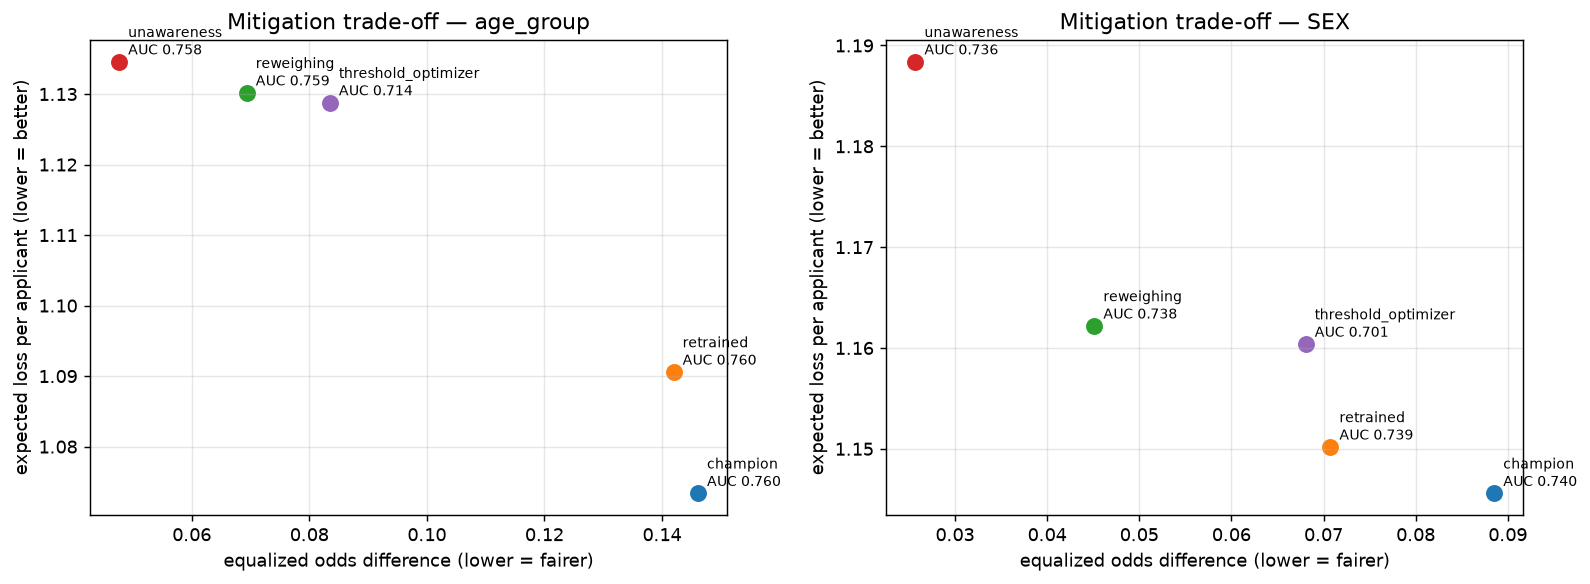

In [6]:
for attribute, result in fairness_report["mitigation"].items():
    table = pd.DataFrame(result["variants"]).set_index("variant")
    display(Markdown(f"**Mitigation theo `{attribute}`** (test rows: {result['test_rows']:,})"))
    display(
        table[
            [
                "demographic_parity_difference",
                "equalized_odds_difference",
                "roc_auc",
                "expected_loss",
                "approval_rate_difference",
                "disparate_impact_ratio",
            ]
        ]
    )
display(Image(filename=str(REPORTS / "figures" / "rai_mitigation_tradeoff.png")))

**Trade-off.** ThresholdOptimizer đạt DPD/EOD thấp nhất nhưng hy sinh ROC-AUC (quyết định ngẫu nhiên hoá theo nhóm và
phải dùng thuộc tính nhạy cảm lúc suy luận — khó chấp nhận về pháp lý). Reweighing và unawareness giảm disparity đáng kể
với chi phí ROC-AUC/expected loss nhỏ → khuyến nghị challenger "unawareness + reweighing" đi qua champion/challenger gate.

## 4. Explainability — SHAP và LIME

SHAP `PermutationExplainer` chạy trên **toàn bộ pipeline** (23 feature gốc → feature engineering → preprocessing →
classifier), trong không gian xác suất: đóng góp cộng lại bằng `P(default) − E[P(default)]`. Ở đây dùng mẫu nhỏ hơn
report để notebook chạy nhanh; kết quả report dùng 500 chủ thẻ.

,feature,mean_abs_shap,share
0,PAY_AMT1,0.0936,0.1733
1,PAY_0,0.0909,0.1681
2,LIMIT_BAL,0.0576,0.1066
3,BILL_AMT2,0.0466,0.0862
4,BILL_AMT5,0.0357,0.0661
5,BILL_AMT6,0.0329,0.0609
6,AGE,0.0263,0.0486
7,PAY_2,0.0250,0.0463
8,PAY_3,0.0175,0.0324
9,BILL_AMT4,0.0145,0.0268


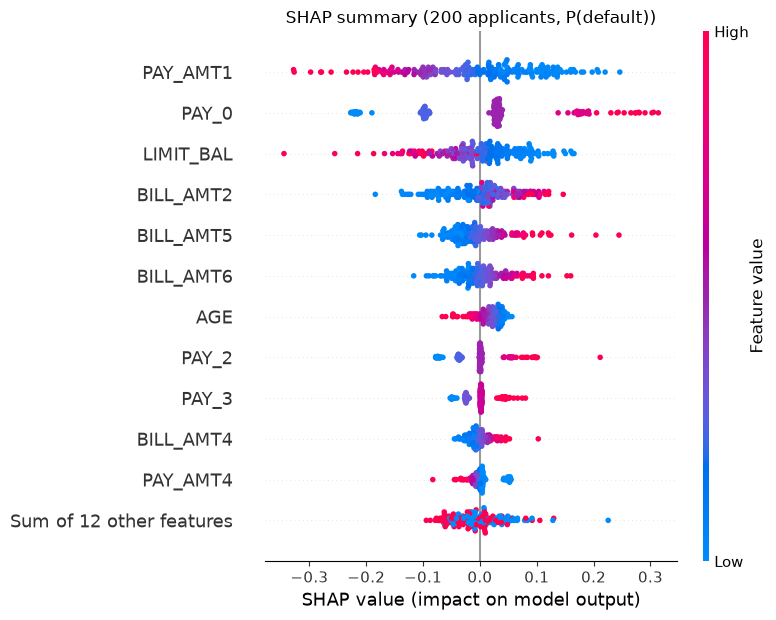

In [7]:
background = x_train.sample(n=cfg.background_size, random_state=cfg.random_state)
sample = features.sample(n=200, random_state=cfg.random_state)
explainer = xai.ShapExplainer(champion.model, background, max_evals=cfg.max_evals, seed=cfg.random_state)
global_explanation = explainer.explain(sample)

importance = xai.global_importance(global_explanation)
display(importance.head(10))
shap.plots.beeswarm(global_explanation, max_display=12, show=False)
plt.title("SHAP summary (200 cardholders, P(default))")
plt.tight_layout()
plt.show()

In [8]:
report_top = [item["feature"] for item in explain_report["global_importance"][:5]]
live_top = importance["feature"].head(5).tolist()
print("Top-5 report (500 rows):", report_top)
print("Top-5 live   (200 rows):", live_top)
print("Overlap:", len(set(report_top) & set(live_top)), "/ 5")

Top-5 report (500 rows): ['PAY_0', 'PAY_AMT1', 'LIMIT_BAL', 'BILL_AMT2', 'BILL_AMT5']
Top-5 live   (200 rows): ['PAY_AMT1', 'PAY_0', 'LIMIT_BAL', 'BILL_AMT2', 'BILL_AMT5']
Overlap: 5 / 5


### Local: ba chủ thẻ đại diện APPROVE / REVIEW / DECLINE

`select_profiles` chọn chủ thẻ có xác suất gần trung vị của từng vùng quyết định. Với mỗi chủ thẻ: SHAP waterfall,
LIME (cùng chủ thẻ) và độ đồng thuận (overlap top-k và cùng dấu).

#### APPROVE — P(default) = 0.245

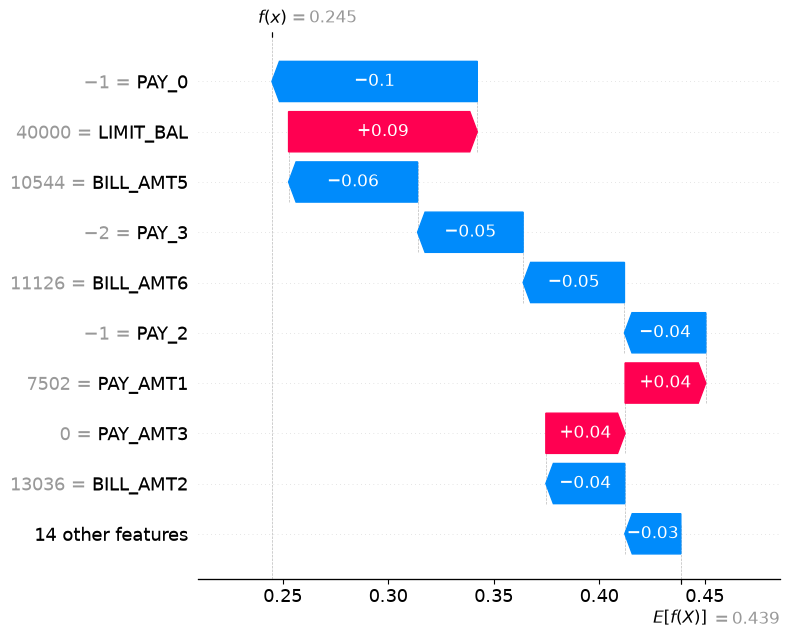

,feature,rule,weight
0,LIMIT_BAL,LIMIT_BAL <= 60000.00,0.1971
1,PAY_0,PAY_0 <= -1.00,-0.1762
2,PAY_AMT1,2952.50 < PAY_AMT1 <= 10836.50,0.1056
3,BILL_AMT5,BILL_AMT5 <= 10566.25,-0.0578
4,PAY_2,PAY_2 <= -1.00,-0.0553


#### REVIEW — P(default) = 0.418

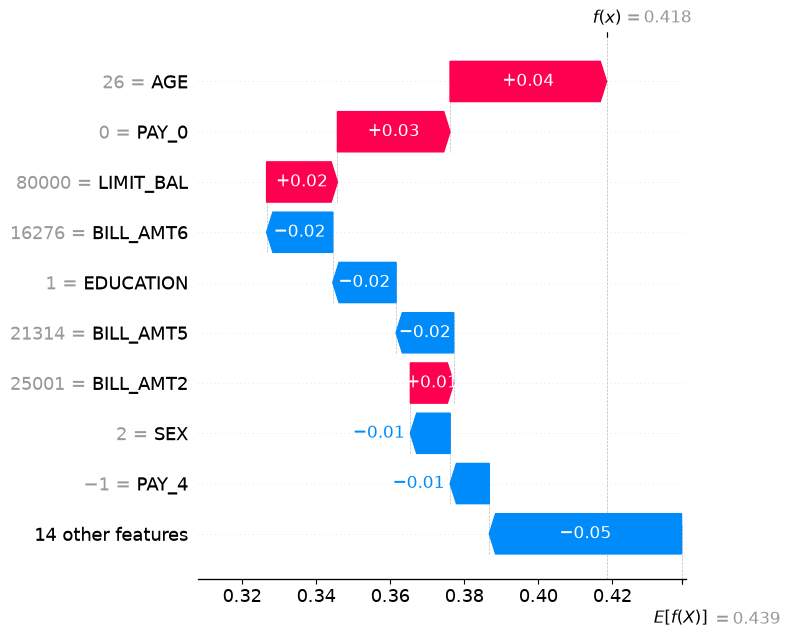

,feature,rule,weight
0,BILL_AMT6,10603.00 < BILL_AMT6 <= 24982.00,-0.0448
1,BILL_AMT5,10566.25 < BILL_AMT5 <= 25512.50,-0.0405
2,AGE,AGE <= 33.00,0.0343
3,PAY_5,PAY_5 <= -1.00,-0.0228
4,BILL_AMT4,11148.00 < BILL_AMT4 <= 26048.00,-0.0224


#### DECLINE — P(default) = 0.784

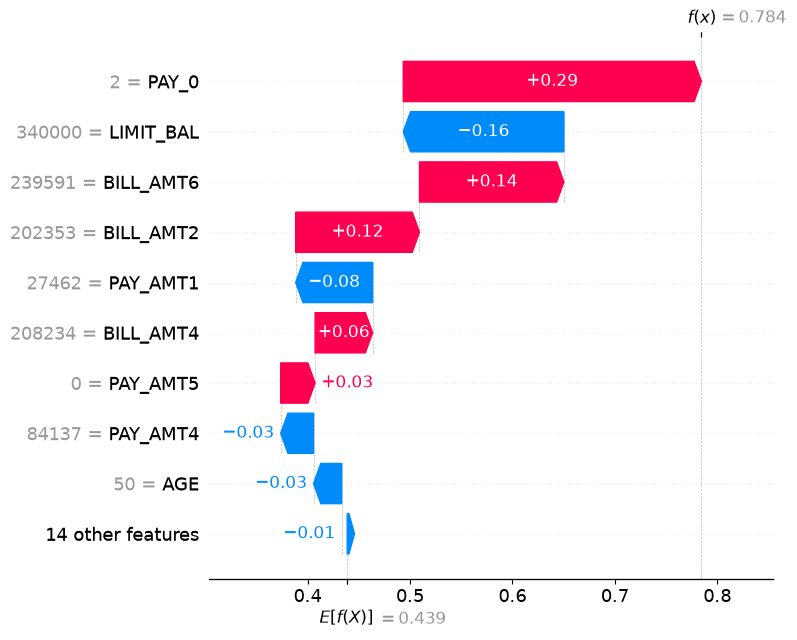

,feature,rule,weight
0,PAY_AMT1,PAY_AMT1 > 26336.00,-0.2775
1,PAY_0,PAY_0 > 0.00,0.2145
2,LIMIT_BAL,LIMIT_BAL > 160000.00,-0.1717
3,BILL_AMT6,BILL_AMT6 > 49670.00,0.1311
4,BILL_AMT2,BILL_AMT2 > 54455.25,0.1004


,k,overlap_at_k,sign_agreement
decision,,,
APPROVE,5,0.6000,1.0000
REVIEW,5,0.4000,1.0000
DECLINE,5,1.0000,1.0000


In [9]:
all_features = features.reset_index(drop=True)
profiles = select_profiles(probabilities, serving.review_threshold, serving.decline_threshold)
assert profiles == {item["decision"]: item["evaluation_row"] for item in explain_report["local"]}
local_explanation = explainer.explain(all_features.iloc[list(profiles.values())])

agreement_rows = []
for position, (decision, row_index) in enumerate(profiles.items()):
    shap_items = xai.local_contributions(local_explanation, position)
    lime_items = xai.lime_explain(
        champion.model,
        x_train,
        all_features.iloc[row_index],
        num_features=cfg.lime_num_features,
        num_samples=cfg.lime_num_samples,
        seed=cfg.random_state,
    )
    display(Markdown(f"#### {decision} — P(default) = {probabilities[row_index]:.3f}"))
    shap.plots.waterfall(local_explanation[position], max_display=10, show=False)
    plt.tight_layout()
    plt.show()
    display(pd.DataFrame(lime_items[: cfg.top_k])[["feature", "rule", "weight"]])
    agreement_rows.append({"decision": decision, **xai.rank_agreement(shap_items, lime_items, k=cfg.top_k)})
pd.DataFrame(agreement_rows).set_index("decision")

**Nhận xét.** SHAP và LIME thống nhất phần lớn yếu tố hàng đầu (đặc biệt `PAY_0`, `LIMIT_BAL`, `PAY_AMT1`) và cùng dấu
trên các feature chung. Khác biệt đến từ việc LIME rời rạc hoá feature liên tục và fit mô hình tuyến tính cục bộ trên mẫu
nhiễu — vì vậy SHAP (có tính cộng dồn chính xác) được chọn cho API; LIME dùng để đối chiếu.

## 5. Giải thích phía serving

`POST /api/v1/explain` so sánh chủ thẻ với **chủ thẻ tham chiếu** (`configs/serving.yaml › explain.reference`) bằng SHAP
permutation (`max_evals=240`, seed cố định → deterministic, ~30 ms sau warm-up). Tổng đóng góp cộng với xác suất tham
chiếu bằng đúng xác suất của chủ thẻ; `risk_factors` sinh từ SHAP thay cho luật cứng.

In [10]:
row_index = profiles["DECLINE"]
cardholder = all_features.iloc[row_index].to_dict()
view = xai.explain_against_reference(
    champion.model,
    cardholder,
    serving.explain_reference,
    ALL_FEATURES,
    max_evals=serving.explain_shap_max_evals,
    seed=serving.explain_seed,
)
contributions = sorted(
    ({"feature": name, "value": cardholder[name], "contribution": value} for name, value in view.contributions.items()),
    key=lambda item: abs(item["contribution"]),
    reverse=True,
)
additivity_error = abs(view.reference_probability + sum(view.contributions.values()) - probabilities[row_index])
print(f"reference P = {view.reference_probability:.4f} | cardholder P = {probabilities[row_index]:.4f}")
print(f"additivity error = {additivity_error:.2e}")
for message in xai.risk_factor_messages(contributions):
    print("-", message)
pd.DataFrame(contributions[:8])

reference P = 0.4382 | cardholder P = 0.7844
additivity error = 0.00e+00
- PAY_0 = 2 (repayment status last month) increases default risk by +25.4 pp
- BILL_AMT6 = 239,591 NTD (bill amount 6 month(s) ago) increases default risk by +19.5 pp
- BILL_AMT4 = 208,234 NTD (bill amount 4 month(s) ago) increases default risk by +5.1 pp


,feature,value,contribution
0,PAY_0,2,0.2543
1,BILL_AMT6,239591,0.1946
2,LIMIT_BAL,340000,-0.1818
3,PAY_AMT1,27462,-0.0689
4,BILL_AMT4,208234,0.0512
5,PAY_AMT5,0,0.0427
6,BILL_AMT2,202353,0.0414
7,AGE,50,-0.0359


## 6. Privacy

- Log JSON tự động thay mọi feature của khách hàng bằng `[REDACTED]` (`credit_risk.config.logging.PII_FIELDS`).
- Định danh rời khỏi service được pseudonymize bằng HMAC-SHA256 với khoá `PSEUDONYMIZATION_KEY` (từ `.env`).
- Bản ghi xuất ra ngoài được generalize (tuổi → dải 10 năm, hạn mức → dải) và bỏ thuộc tính bảo vệ.
- Inference log giữ tối đa 90 ngày: `make purge-logs` (`scripts/purge_inference_logs.py`).

In [11]:
import logging

from credit_risk.config.logging import JsonFormatter
from credit_risk.responsible_ai import privacy

record = logging.LogRecord("demo", logging.INFO, "notebook", 0, "prediction served", None, None)
record.features = cardholder
record.AGE = cardholder["AGE"]
record.default_probability = round(float(probabilities[row_index]), 4)
entry = json.loads(JsonFormatter().format(record))
privacy.assert_no_raw_pii(entry, cardholder)
print(json.dumps({key: entry[key] for key in ("message", "features", "AGE", "default_probability")}, indent=2))

demo_key = os.getenv(privacy.PSEUDONYMIZATION_KEY_ENV) or "notebook-demo-key"
print("pseudonym:", privacy.pseudonymize("customer-000123", key=demo_key))
print("generalized:", {key: value for key, value in privacy.generalize_record(cardholder).items() if key in ("AGE", "LIMIT_BAL")})
print("dropped in exports:", sorted(privacy.DROPPED_IN_EXPORTS))

{
  "message": "prediction served",
  "features": "[REDACTED]",
  "AGE": "[REDACTED]",
  "default_probability": 0.7844
}
pseudonym: 9c5466a7d7ecb9c4
generalized: {'LIMIT_BAL': '200k-500k', 'AGE': '50-59'}
dropped in exports: ['EDUCATION', 'MARRIAGE', 'SEX']


## Kết luận

- Champion vượt ngưỡng cảnh báo fairness ở cả 4 thuộc tính, nặng nhất theo **tuổi** (hệ quả trực tiếp của việc train chỉ
  trên ≥ 30 tuổi) → REVIEW bắt buộc có chuyên viên rủi ro xem xét; challenger "unawareness + reweighing" + retrain với dữ liệu feedback.
- SHAP (global + local) và LIME cho cùng chủ thẻ nhất quán ở các yếu tố chính; SHAP đã thay rule-based `top_risk_factors`
  trong `/api/v1/explain`.
- Thảo luận đạo đức, privacy, giới hạn sử dụng: `docs/06-responsible-ai.md`, `docs/model-card.md`, `docs/data-card.md`.